In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    roc_auc_score
)

In [2]:
X, y = make_classification(
    n_samples=1000,
    n_features=20,
    n_informative=15,
    n_redundant=5,
    n_classes=2,
    random_state=42
)

print("Dataset Shape:")
print("Features:", X.shape)
print("Target:", y.shape)

Dataset Shape:
Features: (1000, 20)
Target: (1000,)


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 800
Testing samples: 200


In [4]:
logistic_model = LogisticRegression(max_iter=1000)

logistic_model.fit(X_train, y_train)

logistic_predictions = logistic_model.predict(X_test)

print("Logistic Regression Model Trained Successfully")

Logistic Regression Model Trained Successfully


In [5]:
print("========== Logistic Regression ==========\n")

print(classification_report(
    y_test,
    logistic_predictions
))

========== Logistic Regression ==========

              precision    recall  f1-score   support

           0       0.83      0.84      0.84       106
           1       0.82      0.81      0.81        94

    accuracy                           0.82       200
   macro avg       0.82      0.82      0.82       200
weighted avg       0.82      0.82      0.82       200



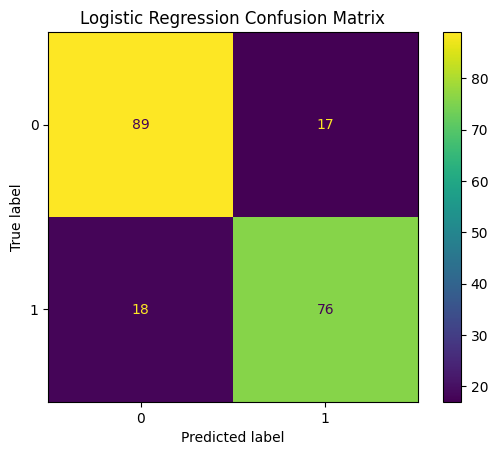

In [6]:
ConfusionMatrixDisplay.from_estimator(
    logistic_model,
    X_test,
    y_test
)

plt.title("Logistic Regression Confusion Matrix")

plt.show()

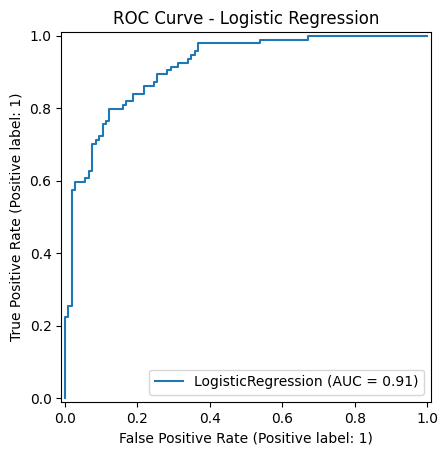

In [7]:
RocCurveDisplay.from_estimator(
    logistic_model,
    X_test,
    y_test
)

plt.title("ROC Curve - Logistic Regression")

plt.show()

In [8]:
random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

random_forest.fit(X_train, y_train)

rf_predictions = random_forest.predict(X_test)

print("Random Forest Model Trained Successfully")

Random Forest Model Trained Successfully


In [9]:
print("========== Random Forest ==========\n")

print(classification_report(
    y_test,
    rf_predictions
))

========== Random Forest ==========

              precision    recall  f1-score   support

           0       0.92      0.89      0.90       106
           1       0.88      0.91      0.90        94

    accuracy                           0.90       200
   macro avg       0.90      0.90      0.90       200
weighted avg       0.90      0.90      0.90       200



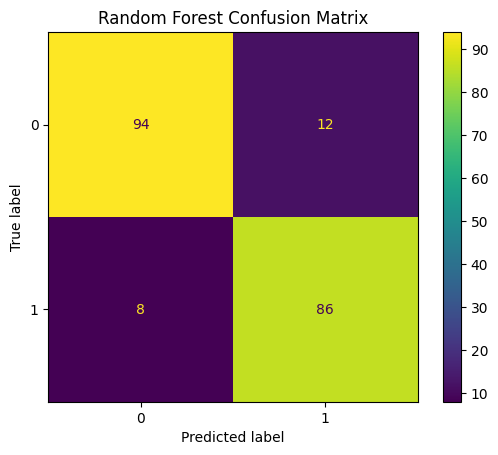

In [10]:
ConfusionMatrixDisplay.from_estimator(
    random_forest,
    X_test,
    y_test
)

plt.title("Random Forest Confusion Matrix")

plt.show()

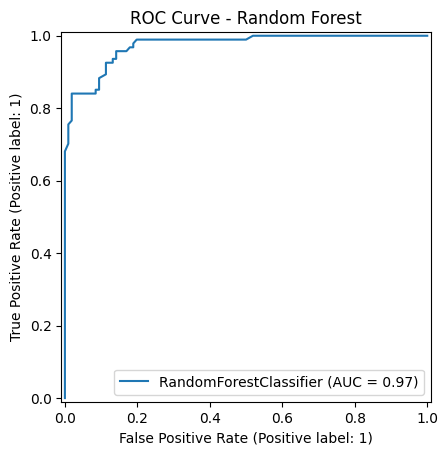

In [11]:
RocCurveDisplay.from_estimator(
    random_forest,
    X_test,
    y_test
)

plt.title("ROC Curve - Random Forest")

plt.show()

In [12]:
comparison = pd.DataFrame({

    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],

    "Accuracy": [
        accuracy_score(y_test, logistic_predictions),
        accuracy_score(y_test, rf_predictions)
    ],

    "Precision": [
        precision_score(y_test, logistic_predictions),
        precision_score(y_test, rf_predictions)
    ],

    "Recall": [
        recall_score(y_test, logistic_predictions),
        recall_score(y_test, rf_predictions)
    ],

    "ROC-AUC": [
        roc_auc_score(
            y_test,
            logistic_model.predict_proba(X_test)[:,1]
        ),

        roc_auc_score(
            y_test,
            random_forest.predict_proba(X_test)[:,1]
        )
    ]
})

comparison

,Model,Accuracy,Precision,Recall,ROC-AUC
0,Logistic Regression,0.825,0.817204,0.808511,0.913689
1,Random Forest,0.900,0.877551,0.914894,0.973454


In [13]:
best_model = comparison.loc[
    comparison["Accuracy"].idxmax()
]

print("Best Performing Model\n")

print(best_model)

Best Performing Model

Model        Random Forest
Accuracy               0.9
Precision         0.877551
Recall            0.914894
ROC-AUC           0.973454
Name: 1, dtype: object


In [14]:
print("PROJECT SUMMARY")
print("-" * 40)

print("1. Created a binary classification dataset.")

print("2. Trained Logistic Regression.")

print("3. Evaluated Logistic Regression.")

print("4. Plotted Confusion Matrix.")

print("5. Plotted ROC Curve.")

print("6. Trained Random Forest.")

print("7. Compared both models.")

print("8. Selected the better performing model.")

PROJECT SUMMARY
----------------------------------------
1. Created a binary classification dataset.
2. Trained Logistic Regression.
3. Evaluated Logistic Regression.
4. Plotted Confusion Matrix.
5. Plotted ROC Curve.
6. Trained Random Forest.
7. Compared both models.
8. Selected the better performing model.
